In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [2]:
df = pd.read_csv("CC_GENERAL.csv")  # dataset repo qovluğunda olmalıdır
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='str')

In [4]:
# CUST_ID                         -> Müştərinin unikal identifikasiya nömrəsi
# BALANCE                         -> Müştərinin kredit kartındakı cari balansı
# BALANCE_FREQUENCY               -> Balansın nə qədər tez-tez yeniləndiyini göstərir
# PURCHASES                      -> Ümumi alış-veriş məbləği
# ONEOFF_PURCHASES               -> Birdəfəlik edilən alış-verişlərin ümumi məbləği
# INSTALLMENTS_PURCHASES        -> Taksitlə edilən alış-verişlərin ümumi məbləği
# CASH_ADVANCE                   -> Kredit kartından nağd avans kimi çıxarılan ümumi məbləğ
# PURCHASES_FREQUENCY            -> Alış-veriş etmə tezliyi
# ONEOFF_PURCHASES_FREQUENCY     -> Birdəfəlik alış-veriş etmə tezliyi
# PURCHASES_INSTALLMENTS_FREQUENCY -> Taksitli alış-veriş etmə tezliyi
# CASH_ADVANCE_FREQUENCY         -> Nağd avansdan istifadə etmə tezliyi
# CASH_ADVANCE_TRX               -> Nağd avans əməliyyatlarının sayı
# PURCHASES_TRX                  -> Ümumi alış-veriş əməliyyatlarının sayı
# CREDIT_LIMIT                   -> Kredit kartı üzrə müəyyən edilmiş kredit limiti
# PAYMENTS                       -> Kredit kartına edilən ümumi ödəniş məbləği
# MINIMUM_PAYMENTS               -> Kredit kartı üzrə minimum ödəniş məbləği
# PRC_FULL_PAYMENT               -> Müştərinin balansını tam ödəmə faizi
# TENURE                         -> Müştərinin kredit kartından istifadə etdiyi müddət (ay)

In [5]:
df.shape

(8950, 18)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [9]:
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(
    df["CREDIT_LIMIT"].median()
)

In [10]:
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(
    df["MINIMUM_PAYMENTS"].median()
)

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


### Qeyd: CASH_ADVANCE_FREQUENCY anomaliyası

`describe()` nəticəsində `CASH_ADVANCE_FREQUENCY` dəyişəninin maksimum dəyəri **1.5**-dir. Nəzəri olaraq bu, "tezlik" (frequency) göstəricisi olduğu üçün 0–1 aralığında olmalıdır. 1-dən yuxarı dəyərlər datasetin özündəki hesablama metodologiyasından qaynaqlanır (bu, `CC_GENERAL.csv` — klassik Kaggle Credit Card dataset-ində tanınan bir xüsusiyyətdir) və data xətası kimi deyil, mənbə dataset-in orijinal formatı kimi qəbul edilib. Bu layihədə dəyişən olduğu kimi saxlanılıb, çünki silinməsi/korreksiyası əlavə fərziyyə tələb edir və orijinal Kaggle mənbəyində də bu şəkildə mövcuddur.

## 1. Müştərilərin alış-veriş davranışı necədir?

In [12]:
df[[
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE"
]].sum()

ONEOFF_PURCHASES          5.302314e+06
INSTALLMENTS_PURCHASES    3.679055e+06
CASH_ADVANCE              8.760896e+06
dtype: float64

Ən yüksək məbləğ CASH_ADVANCE-dır.
Yəni bu datasetdə müştərilər alış-verişdən çox kredit kartından nağd avans kimi istifadə etməyə meyllidirlər.
Sonra:

ONEOFF_PURCHASES > INSTALLMENTS_PURCHASES

Deməli, alış-veriş edən müştərilər arasında birdəfəlik alışların ümumi məbləği taksitli alışlardan daha yüksəkdir.
Amma bir şeyə diqqət edək:

Bu nəticə “müştərilərin çoxu nağd avans istifadə edir” demək deyil. Biz burada yalnız ümumi məbləğə baxırıq. Məsələn, az sayda müştəri çox böyük məbləğdə CASH_ADVANCE etmiş ola bilər.

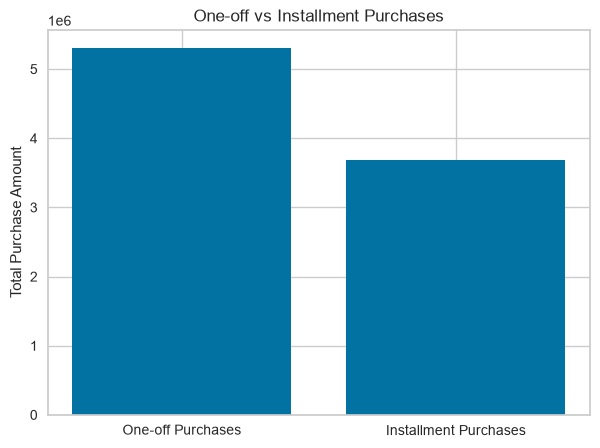

In [13]:
purchase_types = {
    "One-off Purchases": df["ONEOFF_PURCHASES"].sum(),
    "Installment Purchases": df["INSTALLMENTS_PURCHASES"].sum()
}
plt.figure(figsize=(7, 5))
plt.bar(purchase_types.keys(), purchase_types.values())

plt.title("One-off vs Installment Purchases")
plt.ylabel("Total Purchase Amount")
plt.show()

In [14]:
print("One-off:", (df["ONEOFF_PURCHASES"] > 0).sum())
print("Installment:", (df["INSTALLMENTS_PURCHASES"] > 0).sum())

One-off: 4648
Installment: 5034


In [15]:
oneoff_only = (
    (df["ONEOFF_PURCHASES"] > 0) &
    (df["INSTALLMENTS_PURCHASES"] == 0)
).mean() * 100

installment_only = (
    (df["ONEOFF_PURCHASES"] == 0) &
    (df["INSTALLMENTS_PURCHASES"] > 0)
).mean() * 100

both = (
    (df["ONEOFF_PURCHASES"] > 0) &
    (df["INSTALLMENTS_PURCHASES"] > 0)
).mean() * 100

nothing= (
    (df["ONEOFF_PURCHASES"] == 0) &
    (df["INSTALLMENTS_PURCHASES"] == 0)
).mean() * 100

print("Only One-off:", oneoff_only)
print("Only Installment:", installment_only)
print("Both:", both)
print("Nothing:", nothing)

Only One-off: 20.93854748603352
Only Installment: 25.251396648044693
Both: 30.99441340782123
Nothing: 22.81564245810056


Müştərilərin ən böyük hissəsi (30.99%) həm birdəfəlik, həm də taksitli alış-verişdən istifadə edir. Təkcə taksitli alış edən müştərilərin payı (25.25%) yalnız birdəfəlik alış edən müştərilərdən (20.94%) daha yüksəkdir. Ümumilikdə müştərilərin təxminən 77%-i ən azı bir alış-veriş növündən istifadə edib. Bu nəticə əvvəl hesabladığımız 77.16% alış-veriş edən müştərilərin payına demək olar ki, tam uyğundur. Qalan təxminən 23% müştəri isə heç bir alış-veriş etməyib.

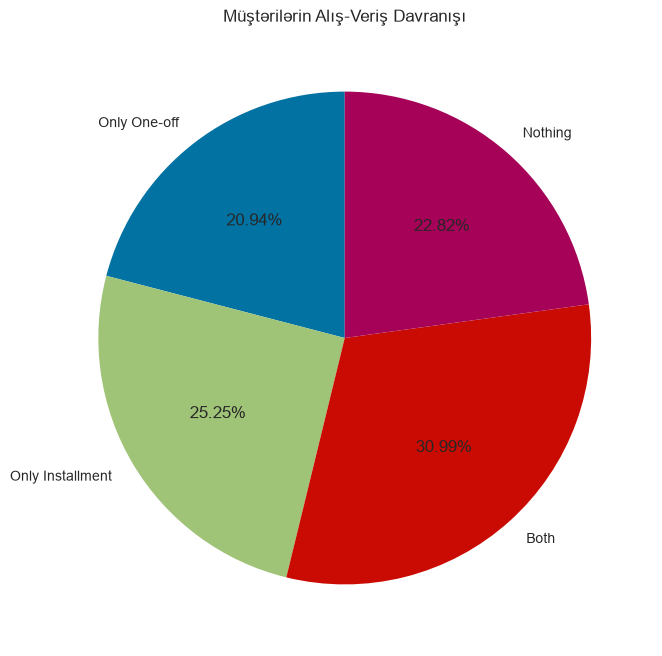

In [16]:
labels = [
    "Only One-off",
    "Only Installment",
    "Both",
    "Nothing"
]

values = [
    oneoff_only,
    installment_only,
    both,
    nothing
]

plt.figure(figsize=(8, 8))
plt.pie(
    values,
    labels=labels,
    autopct="%1.2f%%",
    startangle=90
)
plt.title("Müştərilərin Alış-Veriş Davranışı")
plt.show()

## 2. Müştərilər kredit kartından daha çox alış-veriş üçün, yoxsa nağd avans üçün istifadə edirlər?

In [17]:
df[["PURCHASES", "CASH_ADVANCE"]].sum()

PURCHASES       8.978683e+06
CASH_ADVANCE    8.760896e+06
dtype: float64

Müştərilər ümumi məbləğ baxımından kredit kartından alış-veriş üçün daha çox istifadə ediblər. PURCHASES üzrə ümumi məbləğ 8.98 milyon, CASH_ADVANCE üzrə isə 8.76 milyon təşkil edir. Bu, alış-veriş məbləğinin CASH_ADVANCE məbləğindən bir qədər yüksək olduğunu göstərir.

In [18]:
(df["CASH_ADVANCE"] > 0).mean() * 100

np.float64(48.29050279329609)

In [19]:
(df["PURCHASES"] > 0).mean() * 100

np.float64(77.16201117318435)

Müştərilərin 77.16%-i alış-veriş edib, **CASH_ADVANCE** istifadə edən müştərilərin faizi isə 48.29%-dir. Bu nəticə göstərir ki, müştərilər kredit kartından nağd avans götürməkdən daha çox alış-veriş üçün istifadə edirlər.

In [20]:
only_purchases = (
    (df["PURCHASES"] > 0) &
    (df["CASH_ADVANCE"] == 0)
).mean() * 100

only_cash_advance = (
    (df["PURCHASES"] == 0) &
    (df["CASH_ADVANCE"] > 0)
).mean() * 100

both = (
    (df["PURCHASES"] > 0) &
    (df["CASH_ADVANCE"] > 0)
).mean() * 100

nothing = (
    (df["PURCHASES"] == 0) &
    (df["CASH_ADVANCE"] == 0)
).mean() * 100

print("Only Purchases:", only_purchases)
print("Only Cash Advance:", only_cash_advance)
print("Both:", both)
print("Nothing:", nothing)

Only Purchases: 51.69832402234636
Only Cash Advance: 22.8268156424581
Both: 25.463687150837988
Nothing: 0.0111731843575419


Müştərilərin 51.70%-i yalnız alış-veriş edir, 22.83%-i yalnız **CASH_ADVANCE** istifadə edir, 25.46%-i isə hər iki xidmətdən istifadə edir. Cəmi 0.01% müştəri hər iki fəaliyyətdən istifadə etmir. Bu nəticə göstərir ki, kredit kartı müştərilər tərəfindən daha çox alış-veriş məqsədilə istifadə olunur, lakin əhəmiyyətli bir hissə həm alış-veriş, həm də nağd avans xidmətindən istifadə edir.

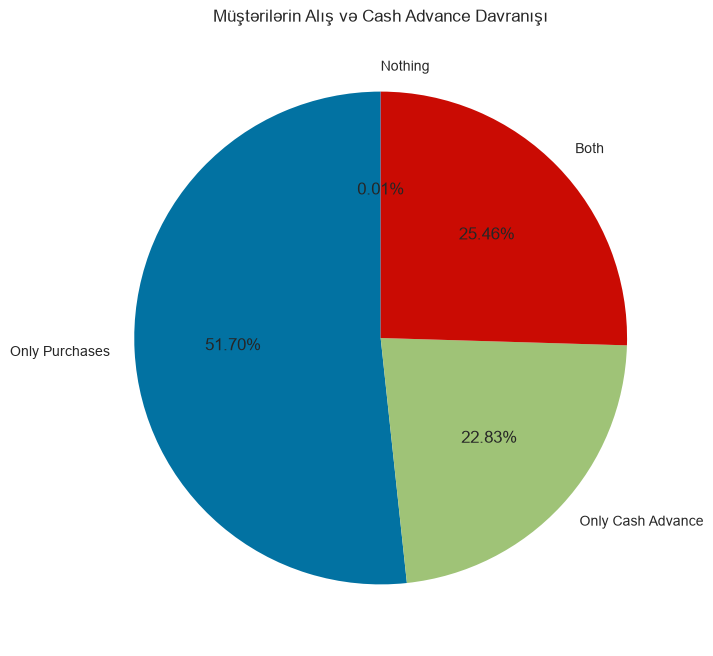

In [21]:
labels = [
    "Only Purchases",
    "Only Cash Advance",
    "Both",
    "Nothing"
]

values = [
    only_purchases,
    only_cash_advance,
    both,
    nothing
]

plt.figure(figsize=(8, 8))

plt.pie(
    values,
    labels=labels,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Müştərilərin Alış və Cash Advance Davranışı")
plt.show()

## 3. Çox alış-veriş edən müştərilər eyni zamanda çox nağd avans istifadə edirlərmi?

In [22]:
df[["PURCHASES", "CASH_ADVANCE"]].corr()

,PURCHASES,CASH_ADVANCE
PURCHASES,1.000000,-0.051474
CASH_ADVANCE,-0.051474,1.000000


Müştərilərin kredit kartından istifadə məqsədləri bir-birindən fərqlənir.PURCHASES və CASH_ADVANCE arasında demək olar ki, heç bir xətti əlaqə yoxdur. Çox alış-veriş edən müştəri mütləq çox nağd avans istifadə etmir və əksinə. Bu, müştərilərin bir hissəsinin kartı əsasən alış-veriş üçün, digər hissəsinin isə nağd pul ehtiyacı üçün istifadə etdiyini göstərir.

## 4. Müştərilərin kredit kartından istifadə tezliyi onların alış-veriş məbləği ilə əlaqəlidirmi?

In [23]:
df[["BALANCE_FREQUENCY", "PURCHASES"]].corr()

,BALANCE_FREQUENCY,PURCHASES
BALANCE_FREQUENCY,1.000000,0.133674
PURCHASES,0.133674,1.000000


BALANCE_FREQUENCY və PURCHASES arasında 0.134 korrelyasiya müşahidə olunmuşdur. Bu, iki dəyişən arasında çox zəif müsbət əlaqənin olduğunu göstərir. Deməli, kart balansından istifadə tezliyi müştərinin alış-veriş məbləğini əhəmiyyətli dərəcədə izah etmir.

## 5. Müştərilərin kredit limitinin yüksək olması onların daha çox alış-veriş etməsi ilə əlaqəlidirmi?

In [24]:
df[["CREDIT_LIMIT", "PURCHASES"]].corr()

,CREDIT_LIMIT,PURCHASES
CREDIT_LIMIT,1.000000,0.356977
PURCHASES,0.356977,1.000000


- Kredit limiti artdıqca alış-veriş məbləğinin də artması tendensiyası müşahidə olunur. Lakin korrelyasiyanın 0.357 olması əlaqənin güclü olmadığını göstərir. Buna görə yüksək kredit limitinə sahib olmaq mütləq yüksək alış-veriş demək deyil.
- Kredit limiti yüksək olan müştərilər ümumiyyətlə daha çox alış-veriş etməyə meyllidirlər, lakin bu həmişə belə deyil.

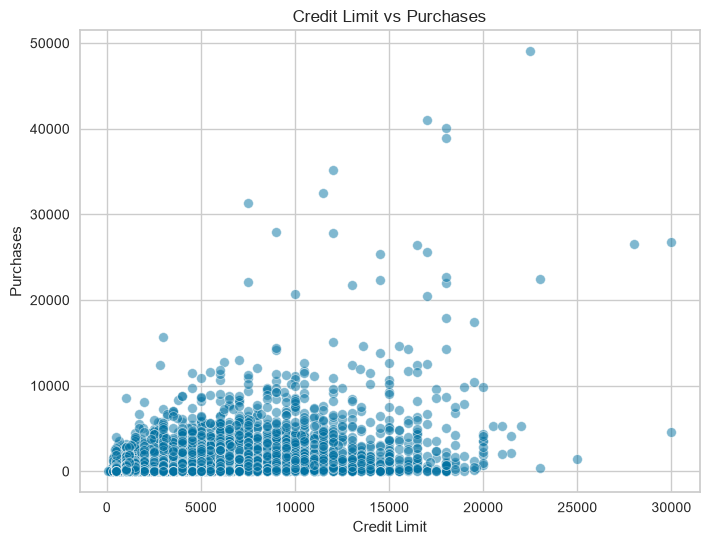

In [25]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="CREDIT_LIMIT",
    y="PURCHASES",
    alpha=0.5
)

plt.title("Credit Limit vs Purchases")
plt.xlabel("Credit Limit")
plt.ylabel("Purchases")
plt.show()

## 6. Kredit kartından daha uzun müddət istifadə edən müştərilər daha çox alış-veriş edirlərmi?

In [26]:
df[["TENURE", "PURCHASES"]].corr()

,TENURE,PURCHASES
TENURE,1.000000,0.086288
PURCHASES,0.086288,1.000000


TENURE və PURCHASES arasında 0.086 korrelyasiya müşahidə olunmuşdur. Bu, kartdan istifadə müddətinin müştərinin alış-veriş məbləği ilə demək olar ki, əlaqəli olmadığını göstərir. Deməli, müştərinin kartdan daha uzun müddət istifadə etməsi onun daha çox alış-veriş etməsi demək deyil.

## 7. Müştərinin kredit limiti ilə istifadə etdiyi balans arasında əlaqə varmı?

In [27]:
df[["BALANCE", "CREDIT_LIMIT"]].corr()

,BALANCE,CREDIT_LIMIT
BALANCE,1.000000,0.531296
CREDIT_LIMIT,0.531296,1.000000


BALANCE ilə CREDIT_LIMIT arasında 0.531 korrelyasiya müşahidə olunur. Bu, kredit limiti ilə müştərinin balansı arasında orta səviyyəli müsbət əlaqə olduğunu göstərir. Yəni kredit limiti artdıqca balansın da artmağa meylli olduğu müşahidə olunur.

## 8. Müştərilər kredit kartı balanslarını tam ödəməyə nə qədər meyllidirlər?

In [28]:
df["PRC_FULL_PAYMENT"].describe()

count    8950.000000
mean        0.153715
std         0.292499
min         0.000000
25%         0.000000
50%         0.000000
75%         0.142857
max         1.000000
Name: PRC_FULL_PAYMENT, dtype: float64

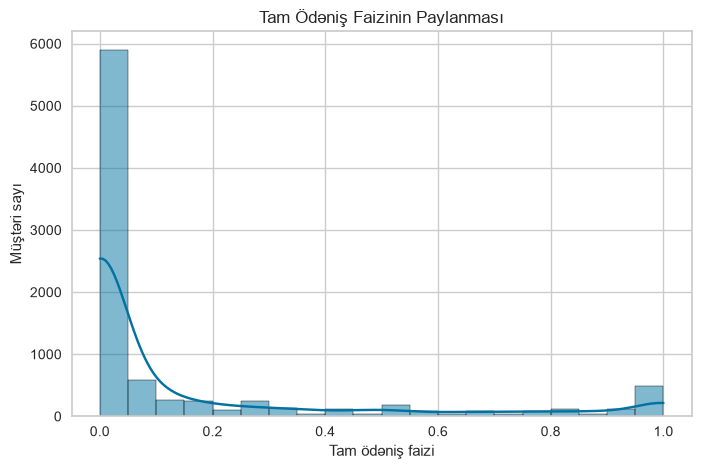

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(
    df["PRC_FULL_PAYMENT"],
    bins=20,
    kde=True
)
plt.title("Tam Ödəniş Faizinin Paylanması")
plt.xlabel("Tam ödəniş faizi")
plt.ylabel("Müştəri sayı")

plt.show()

PRC_FULL_PAYMENT göstəricisinin paylanması 0-a doğru güclü şəkildə cəmlənmişdir. Bu, müştərilərin böyük hissəsinin balansını tam ödəmə faizinin çox aşağı olduğunu göstərir.Yəni əksər müştərilər balanslarını tam ödəməyə çox meylli deyil. Bununla yanaşı, 1-ə yaxın dəyərə sahib olan ayrıca müştəri qrupu da mövcuddur və bu müştərilər balanslarını tam ödəməyə daha çox meyllidirlər.

## 9. Müştərilər kredit kartından istifadə etdikcə daha çox ödəniş edirlərmi?

In [30]:
df[["TENURE", "PAYMENTS"]].corr()

,TENURE,PAYMENTS
TENURE,1.000000,0.106136
PAYMENTS,0.106136,1.000000


TENURE və PAYMENTS arasında 0.106 korrelyasiya müşahidə olunur. Bu, iki dəyişən arasında çox zəif müsbət əlaqənin olduğunu göstərir. Yəni müştərinin kartdan istifadə müddətinin uzun olması onun etdiyi ödəniş məbləğinin yüksək olması ilə ciddi şəkildə əlaqəli deyil.

## 10. Müştərilər etdikləri alış-verişlərə görə nə qədər ödəniş edirlər?

In [31]:
df[["PURCHASES", "PAYMENTS"]].corr()

,PURCHASES,PAYMENTS
PURCHASES,1.000000,0.603264
PAYMENTS,0.603264,1.000000


PURCHASES və PAYMENTS arasında 0.603 korrelyasiya müşahidə olunur. Bu, orta–güclü müsbət əlaqəni göstərir. Yəni daha çox alış-veriş edən müştərilərin kredit kartına etdiyi ödəniş məbləği də ümumiyyətlə daha yüksək olur.

## 11. Müştərilərin kredit kartından istifadə tezliyi hansı dəyişənlərlə əlaqəlidir?

In [32]:
corr = df.corr(numeric_only=True)["BALANCE_FREQUENCY"].sort_values(ascending=False)
print(corr)

BALANCE_FREQUENCY                   1.000000
BALANCE                             0.322412
PURCHASES_FREQUENCY                 0.229715
ONEOFF_PURCHASES_FREQUENCY          0.202415
CASH_ADVANCE_FREQUENCY              0.191873
PURCHASES_TRX                       0.189626
PURCHASES_INSTALLMENTS_FREQUENCY    0.176079
CASH_ADVANCE_TRX                    0.141555
PURCHASES                           0.133674
MINIMUM_PAYMENTS                    0.131181
INSTALLMENTS_PURCHASES              0.124292
TENURE                              0.119776
ONEOFF_PURCHASES                    0.104323
CASH_ADVANCE                        0.099388
CREDIT_LIMIT                        0.095931
PAYMENTS                            0.065008
PRC_FULL_PAYMENT                   -0.095082
Name: BALANCE_FREQUENCY, dtype: float64


BALANCE_FREQUENCY ilə ən güclü əlaqə BALANCE dəyişəni ilə müşahidə olunur (r = 0.322). Bu, balansı daha yüksək olan müştərilərdə balansın yenilənmə tezliyinin də müəyyən qədər yüksək olmağa meylli olduğunu göstərir. Digər dəyişənlərlə korrelyasiyalar isə zəifdir.

## 12. Kredit limiti ilə CASH_ADVANCE arasında əlaqə varmı?

In [33]:
df[["CREDIT_LIMIT", "CASH_ADVANCE"]].corr()

,CREDIT_LIMIT,CASH_ADVANCE
CREDIT_LIMIT,1.000000,0.303997
CASH_ADVANCE,0.303997,1.000000


CREDIT_LIMIT ilə CASH_ADVANCE arasında 0.304 müsbət korrelyasiya müşahidə olunur. Bu, kredit limiti yüksək olan müştərilərin daha böyük məbləğdə CASH_ADVANCE istifadə etməyə müəyyən qədər meylli olduğunu göstərir. Amma əlaqə çox güclü deyil. Yəni yüksək kredit limiti avtomatik olaraq yüksək CASH_ADVANCE demək deyil.

## 13. Balansı yüksək olan müştərilər daha çox ödəniş edirlərmi?

In [34]:
df[["BALANCE", "PAYMENTS"]].corr()

,BALANCE,PAYMENTS
BALANCE,1.000000,0.322802
PAYMENTS,0.322802,1.000000


BALANCE ilə PAYMENTS arasında 0.323 müsbət korrelyasiya müşahidə olunur. Bu, balansı yüksək olan müştərilərin daha çox ödəniş etməyə müəyyən qədər meylli olduğunu göstərir. Amma əlaqə güclü deyil. Yəni yüksək BALANCE mütləq yüksək PAYMENTS demək deyil.

## 14. Nağd avansdan daha tez-tez istifadə edən müştərilər daha böyük məbləğdə CASH_ADVANCE edirlərmi?

In [35]:
df[["CASH_ADVANCE_FREQUENCY", "CASH_ADVANCE"]].corr()

,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE
CASH_ADVANCE_FREQUENCY,1.000000,0.628522
CASH_ADVANCE,0.628522,1.000000


CASH_ADVANCE_FREQUENCY ilə CASH_ADVANCE arasında 0.629 müsbət korrelyasiya müşahidə olunur. Bu, nağd avansdan daha tez-tez istifadə edən müştərilərin ümumilikdə daha yüksək məbləğdə CASH_ADVANCE etdiyini göstərir.

# 15. Borcunu tam ödəmə faizi yüksək olan müştərilərin balansı daha aşağıdırmı?

In [36]:
df[["PRC_FULL_PAYMENT", "BALANCE"]].corr()

,PRC_FULL_PAYMENT,BALANCE
PRC_FULL_PAYMENT,1.000000,-0.318959
BALANCE,-0.318959,1.000000


PRC_FULL_PAYMENT ilə BALANCE arasında -0.319 mənfi korrelyasiya müşahidə olunur. Bu, borcunu tam ödəmə faizi yüksək olan müştərilərin daha aşağı balansa malik olmağa meylli olduğunu göstərir.

<h2 align="center"><b>Feature Engineering</b></h2>

### Feature Engineering

Mövcud dəyişənlərdən müştərilərin kredit istifadəsini və kart aktivliyini daha yaxşı ifadə edən yeni dəyişənlər yaradılır. Məqsəd eyni məlumatı təkrarlamaq deyil, analiz və klaster **interpretasiyası** üçün daha faydalı göstəricilər əldə etməkdir. **Qeyd:** Bu dəyişənlər (`BALANCE_TO_LIMIT`, `TOTAL_TRANSACTIONS`, `HAS_CASH_ADVANCE`, `HAS_PURCHASES`) artıq mövcud sütunların törəməsi olduğu üçün (multicollinearity yaratmamaq üçün) clustering feature dəstindən (`X`) çıxarılıb — onlar yalnız klaster profillərini izah etmək üçün istifadə olunur, modelin özündə iştirak etmir.

In [37]:
df["BALANCE_TO_LIMIT"] = df["BALANCE"] / df["CREDIT_LIMIT"]

Müştərinin kredit limitindən nə qədər istifadə etdiyini müəyyən etmək üçün BALANCE_TO_LIMIT dəyişəni yaradılır. Bu göstərici müştərinin kredit limitinə nisbətən borc yükünü daha aydın göstərir.

In [38]:
df["TOTAL_TRANSACTIONS"] = (
    df["PURCHASES_TRX"] + df["CASH_ADVANCE_TRX"]
)

Müştərinin ümumi kart aktivliyini ölçmək üçün alış-veriş və CASH_ADVANCE əməliyyatlarının sayı birləşdirilərək TOTAL_TRANSACTIONS dəyişəni yaradılır.

In [39]:
df["HAS_CASH_ADVANCE"] = (df["CASH_ADVANCE"] > 0).astype(int)

Müştərinin CASH_ADVANCE istifadə edib-etmədiyini göstərən binary dəyişən yaratmaq üçün HAS_CASH_ADVANCE yaradılır. 1 istifadə etdiyini, 0 isə istifadə etmədiyini göstərir.

In [40]:
df["HAS_PURCHASES"] = (df["PURCHASES"] > 0).astype(int)

Müştərinin alış-veriş edib-etmədiyini göstərmək üçün HAS_PURCHASES dəyişəni yaradılır. 1 alış-veriş etdiyini, 0 isə etmədiyini göstərir.

In [41]:
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,...,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,BALANCE_TO_LIMIT,TOTAL_TRANSACTIONS,HAS_CASH_ADVANCE,HAS_PURCHASES
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,...,2,1000.0,201.802084,139.509787,0.000000,12,0.040901,2,0,1
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,...,0,7000.0,4103.032597,1072.340217,0.222222,12,0.457495,4,1,0
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,...,12,7500.0,622.066742,627.284787,0.000000,12,0.332687,12,0,1
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,...,1,7500.0,0.000000,312.343947,0.000000,12,0.222223,2,1,1
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,...,1,1200.0,678.334763,244.791237,0.000000,12,0.681429,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,...,6,1000.0,325.594462,48.886365,0.500000,6,0.028494,6,0,1
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,...,6,1000.0,275.861322,312.343947,0.000000,6,0.019183,6,0,1
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,...,5,1000.0,81.270775,82.418369,0.250000,6,0.023399,5,0,1
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,...,0,500.0,52.549959,55.755628,0.250000,6,0.026915,2,1,0


<h2 align="center"><b>Outlier Analysis</b></h2>

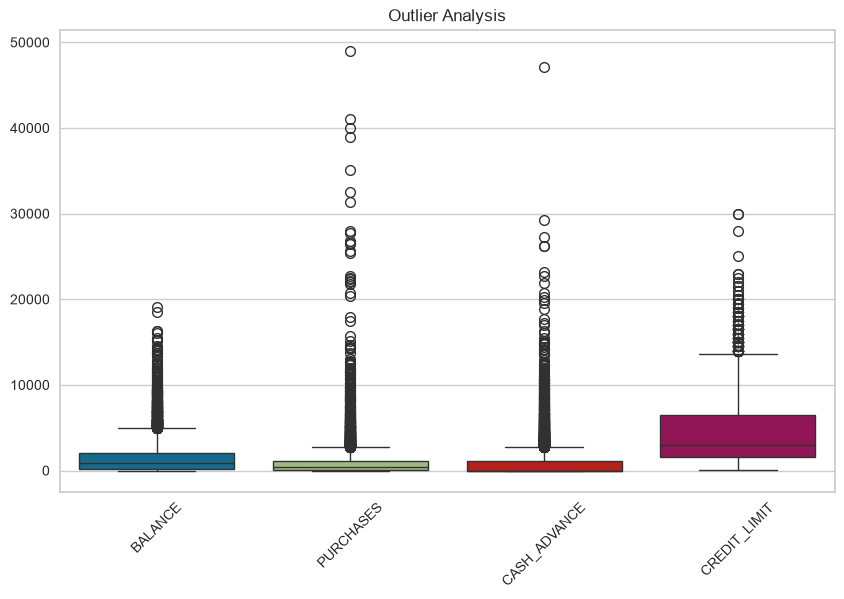

In [42]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[
        [
            "BALANCE",
            "PURCHASES",
            "CASH_ADVANCE",
            "CREDIT_LIMIT"
        ]
    ]
)

plt.title("Outlier Analysis")
plt.xticks(rotation=45)
plt.show()

In [43]:
columns = [
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT"
]
for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]
    print(column, "→", len(outliers), "outlier")

BALANCE → 695 outlier
PURCHASES → 808 outlier
CASH_ADVANCE → 1030 outlier
CREDIT_LIMIT → 248 outlier


### Outlier Analysis

IQR metodu ilə outlier-lər müəyyən edildi:

- BALANCE → 695 outlier
- PURCHASES → 808 outlier
- CASH_ADVANCE → 1030 outlier
- CREDIT_LIMIT → 248 outlier

Bu dəyərlərin real müştəri davranışını əks etdirə biləcəyi nəzərə alınaraq outlier-lər silinmədi. Bunun əvəzinə, clustering mərhələsində ekstremal dəyərlərin təsirini azaltmaq üçün uyğun transformation və scaling üsullarından istifadə ediləcək.

<h2 align="center"><b>Scaling</b></h2>

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [45]:
X = df.drop(columns=[
    "CUST_ID",
    "HAS_CASH_ADVANCE",
    "HAS_PURCHASES",
    "BALANCE_TO_LIMIT",
    "TOTAL_TRANSACTIONS"
])

### Korrelyasiya Heatmap-i (Clustering Feature-ləri)

Clustering-ə daxil olan `X` dəyişənləri arasında multicollinearity-ni yoxlamaq üçün korrelyasiya matrisinə baxılır.Korrelyasiya matrisinə əsasən bəzi dəyişənlər arasında yüksək əlaqə müşahidə olunur. Xüsusilə PURCHASES ilə ONEOFF_PURCHASES və INSTALLMENTS_PURCHASES arasında güclü korrelyasiya var. Bunun əsas səbəbi PURCHASES dəyişəninin bu iki dəyişənin cəmi ilə müəyyən olunmasıdır. Bu cür dəyişənlərin birlikdə clustering-ə daxil edilməsi Euclidean distance hesablamasında eyni məlumatın bir neçə dəfə nəzərə alınmasına və bəzi xüsusiyyətlərin klasterləşməyə daha çox təsir etməsinə səbəb ola bilər.

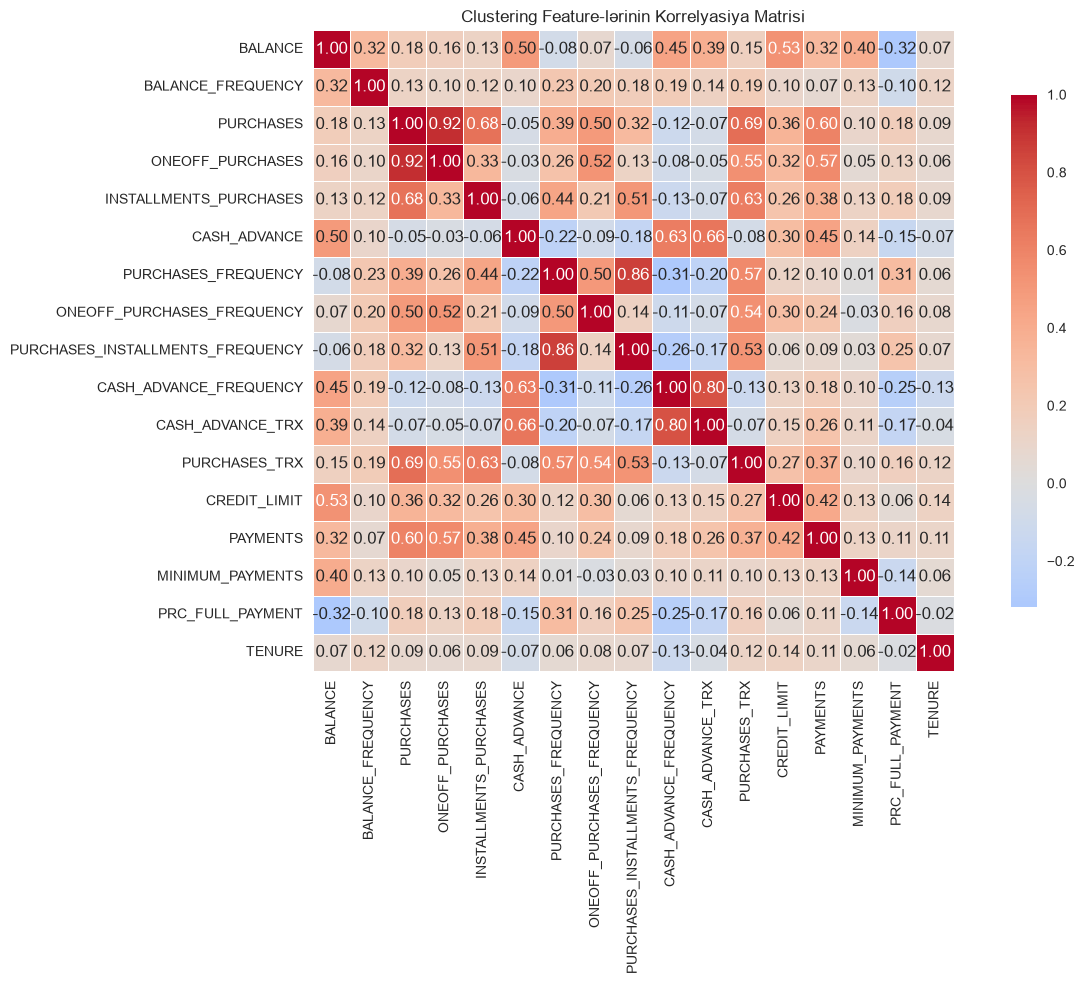

In [46]:
plt.figure(figsize=(14, 10))
corr_matrix = X.corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Clustering Feature-lərinin Korrelyasiya Matrisi")
plt.tight_layout()
plt.show()

**Nəticə:** Heatmap gözlənildiyi kimi bir neçə güclü korrelyasiya aşkarlayır:

- `PURCHASES` ↔ `ONEOFF_PURCHASES`: **0.92** — çox güclü, çünki riyazi olaraq `PURCHASES`-un böyük hissəsini təşkil edir
- `PURCHASES_FREQUENCY` ↔ `PURCHASES_INSTALLMENTS_FREQUENCY`: **0.86**
- `CASH_ADVANCE_FREQUENCY` ↔ `CASH_ADVANCE_TRX`: **0.80**
- `PURCHASES` ↔ `PURCHASES_TRX`: **0.69**

Bu, `PURCHASES` ailəsinin (PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, PURCHASES_TRX) və `CASH_ADVANCE` ailəsinin distance hesablamasında nisbətən artıq çəkiyə malik ola biləcəyini göstərir — çünki bir-birini təkrarlayan siqnal bir neçə dəyişəndə paralel şəkildə mövcuddur. Bununla belə, bu korrelyasiyalar 0.95-dən aşağı olduğu üçün (mükəmməl xətti asılılıq deyil) və hər dəyişən fərqli davranış nüansını daşıdığı üçün (məs. `ONEOFF_PURCHASES` tək-dəfəlik, `INSTALLMENTS_PURCHASES` isə taksitli davranışı göstərir), bu layihədə bütün dəyişənlər saxlanılıb — sadəcə bu addımla şəffaf şəkildə göstərilir ki, hansı dəyişənlər klasterləşməyə nisbətən daha çox təsir edə bilər.

BALANCE, PURCHASES, CASH_ADVANCE kimi dəyişənlərdə IQR analizində çoxlu outlier aşkarlanmışdı.
StandardScaler (mean/std əsaslı) outlier-lərə həssasdır və onların təsirini şişirdə bilər.
Bu səbəbdən median/IQR əsaslı RobustScaler istifadə olunur — outlier-lərin
klaster mərkəzlərinə həddindən artıq təsirini azaldır, amma dəyərləri silmir.

In [47]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [48]:
X_scaled

array([[-0.43226678, -1.63636364, -0.24837108, ..., -0.27973218,
         0.        ,  0.        ],
       [ 1.20937371, -0.81818182, -0.33748873, ...,  1.23005435,
         1.55555556,  0.        ],
       [ 0.84209923,  0.        ,  0.38476593, ...,  0.50973191,
         0.        ,  0.        ],
       ...,
       [-0.44135471, -1.5000045 , -0.20259786, ..., -0.37213466,
         1.75000175, -6.        ],
       [-0.44651662, -1.5000045 , -0.33748873, ..., -0.41528832,
         1.75000175, -6.        ],
       [-0.25997614, -3.        ,  0.68376779, ..., -0.36263312,
         0.        , -6.        ]], shape=(8950, 17))

In [49]:
X_scaled.shape

(8950, 17)

Dəyişənlərin müxtəlif miqyaslarda olması clustering zamanı bəzi dəyişənlərin məsafə hesablamasına daha çox təsir etməsinə səbəb ola bilər. Buna görə bütün numeric dəyişənlər standartlaşdırılır.

**Qeyd:** Outlier Analysis bölməsində `BALANCE`, `PURCHASES` və `CASH_ADVANCE` dəyişənlərində çoxlu sayda outlier aşkarlanmışdı (695–1030 ədəd). Bu dəyərlər silinmədiyi üçün, mean/standart-sapma əsaslı `StandardScaler` əvəzinə **median və IQR əsaslı `RobustScaler`** istifadə edilir. Bu, ekstremal dəyərlərin klaster mərkəzlərini həddindən artıq çəkməsinin qarşısını alır.


### Əlavə Yoxlama: Log-transform effekti

RobustScaler seçimi outlier-lərin klaster mərkəzlərinə təsirini azaldır, lakin dəyişənlərin sağa-əyilmiş (right-skewed) paylanma formasını dəyişmir. Bu bölmədə əsas pipeline-ı dəyişmədən, alternativ bir yanaşma sınaqdan keçirilir: pul-əsaslı dəyişənlərə `log1p` transformu tətbiq edilir, sonra RobustScaler ilə miqyaslanır və k=5 üçün Silhouette Score orijinal yanaşma ilə müqayisə edilir.

In [50]:
# Orijinal (log-transform olmadan, yalnız RobustScaler) üçün Silhouette
kmeans_orig = KMeans(n_clusters=5, random_state=42)
labels_orig = kmeans_orig.fit_predict(X_scaled)
score_orig = silhouette_score(X_scaled, labels_orig)

# Log-transform + RobustScaler üçün Silhouette
log_cols = [
    "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE", "PAYMENTS", "MINIMUM_PAYMENTS", "CREDIT_LIMIT"
]

X_log = X.copy()
for col in log_cols:
    X_log[col] = np.log1p(X_log[col])

scaler_log = RobustScaler()
X_log_scaled = scaler_log.fit_transform(X_log)

kmeans_log = KMeans(n_clusters=5, random_state=42)
labels_log = kmeans_log.fit_predict(X_log_scaled)
score_log = silhouette_score(X_log_scaled, labels_log)

print(f"Orijinal (RobustScaler, k=5) Silhouette Score:        {score_orig:.4f}")
print(f"Log-transform + RobustScaler (k=5) Silhouette Score:  {score_log:.4f}")

Orijinal (RobustScaler, k=5) Silhouette Score:        0.2499
Log-transform + RobustScaler (k=5) Silhouette Score:  0.2599


**Nəticə:** Log-transform + RobustScaler Silhouette Score-u **0.2599**-a çatdırdı, orijinal (yalnız RobustScaler) yanaşma isə **0.2499** verdi — kiçik (≈0.01) amma müsbət fərq. Bu, log-transformun paylanmanın simmetriyasını yaxşılaşdıraraq klasterlərin bir qədər daha aydın ayrılmasına kömək etdiyini göstərir, lakin fərq dramatik deyil. Ona görə əsas pipeline (yalnız RobustScaler) saxlanılıb — sadəlik və şərh olunabilirlik baxımından üstünlük verilib — amma bu nəticə göstərir ki, gələcəkdə model tənzimlənərkən log-transform sınanmağa dəyər alternativ istiqamətdir.

<h2 align="center"><b>Clustering</b></h2>

## PCA

**Qeyd:** PCA bu bölmədə yalnız **vizuallaşdırma** (2D/3D scatter plot) məqsədilə istifadə olunur. Faktiki klasterləşmə (Elbow, Silhouette, K-Means, Agglomerative, DBSCAN, GMM) tam ölçülü standartlaşdırılmış məlumat (`X_scaled`) üzərində aparılır ki, dəyişənlər arasındakı orijinal struktur itirilməsin. PCA yalnız nəticələri qrafikdə göstərmək üçün köməkçi vasitədir, modelin girişi deyil.


In [51]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [52]:
explained_variance = np.cumsum(pca.explained_variance_ratio_)
print(explained_variance)

[0.30264902 0.54828229 0.67153109 0.75177315 0.82132331 0.87458512
 0.90714622 0.93330973 0.9534209  0.96824803 0.97930791 0.98789804
 0.99268219 0.99657131 0.99977749 0.99999903 1.        ]


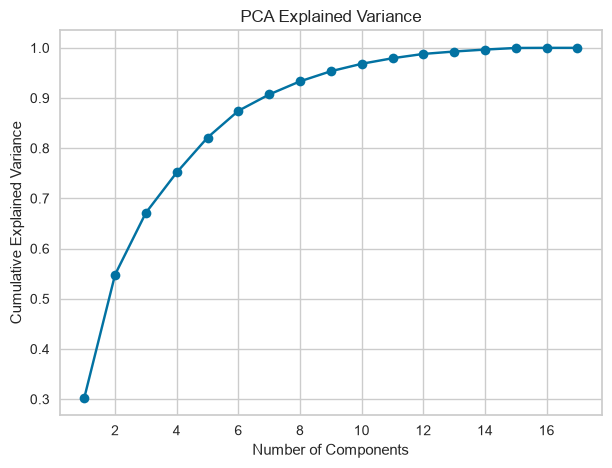

In [53]:
plt.figure(figsize=(7,5))
plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker="o"
)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

In [54]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)

(8950, 9)


## Elbow Method

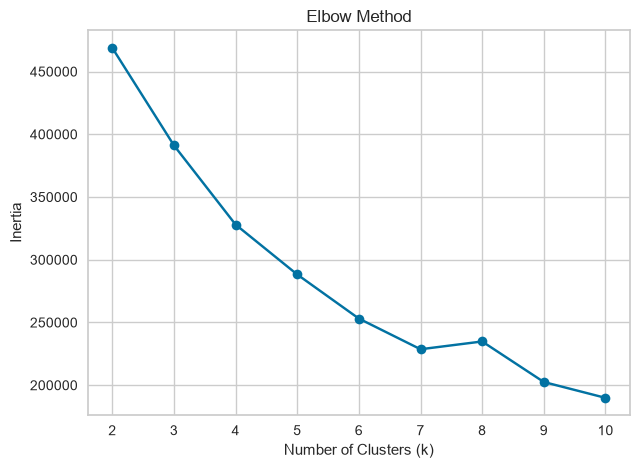

In [55]:
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

## Silhouette Score

In [56]:
scores=[]
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"k = {k}: {score:.4f}")

k = 2: 0.1668
k = 3: 0.2242
k = 4: 0.2351
k = 5: 0.2499
k = 6: 0.2723
k = 7: 0.2919
k = 8: 0.2538
k = 9: 0.2844
k = 10: 0.2817


k = 3: 0.2242


k = 4: 0.2351


k = 5: 0.2499


k = 6: 0.2723


k = 7: 0.2919


k = 8: 0.2538


k = 9: 0.2844


k = 10: 0.2817


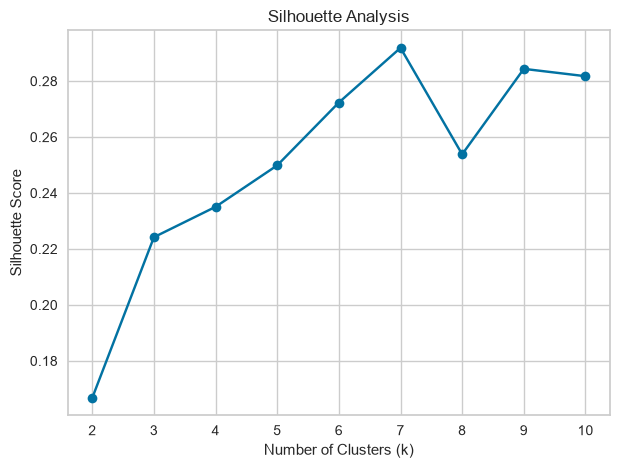

In [57]:
plt.figure(figsize=(7,5))
plt.plot(np.arange(2,11), scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid(True)
plt.show()

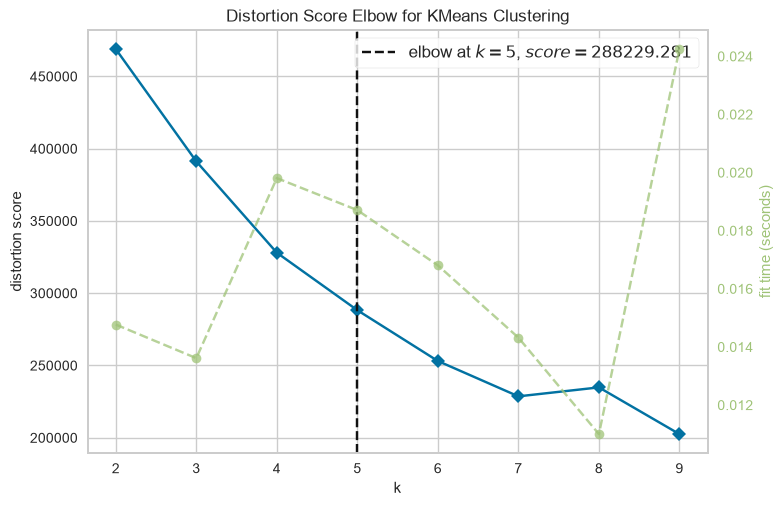

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [58]:
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(estimator = model, k=(2,10),force_model=True)
visualizer.fit(X_scaled)
visualizer.show()

Elbow Method (inertia) qrafikində k=5-6 ətrafında əyilmə (diminishing returns) müşahidə olunur. Silhouette Score isə (RobustScaler ilə) k artdıqca ümumiyyətlə yüksəlir (k=2: 0.167 → k=7: 0.292) — bu, kəskin ayrılmış klasterlərdən çox, hər addımda kiçik outlier qruplarının ayrılmasından qaynaqlanır və 'ideal k' seçimi üçün etibarlı deyil. Buna görə əsas meyar kimi Elbow Method-un diminishing-returns nöqtəsi və biznes interpretasiyası əsas götürülərək **k=5** seçildi.


### Silhouette Score-un PCA fəzasında yoxlanılması

Yuxarıdakı Silhouette Score hesablamaları tam ölçülü (17 dəyişənli) `X_scaled` üzərində aparılıb. Yüksək ölçülü fəzada silhouette göstəricisi az mənalı ola bilər (curse of dimensionality). Bunun üçün eyni hesablama PCA ilə azaldılmış fəzada (`X_pca`, 95% variance, 9 komponent) təkrarlanır və nəticələr müqayisə edilir.

In [59]:
scores_pca = []
for k in range(2, 11):
    kmeans_pca = KMeans(n_clusters=k, random_state=42)
    labels_pca = kmeans_pca.fit_predict(X_pca)
    score_pca = silhouette_score(X_pca, labels_pca)
    scores_pca.append(score_pca)
    print(f"k = {k}: {score_pca:.4f}")

k = 2: 0.6735
k = 3: 0.2474
k = 4: 0.2502
k = 5: 0.2660
k = 6: 0.2844
k = 7: 0.3218
k = 8: 0.3296
k = 9: 0.3106
k = 10: 0.3101


k = 3: 0.2474


k = 4: 0.2502


k = 5: 0.2660


k = 6: 0.2844


k = 7: 0.3218


k = 8: 0.3296


k = 9: 0.3106


k = 10: 0.3101


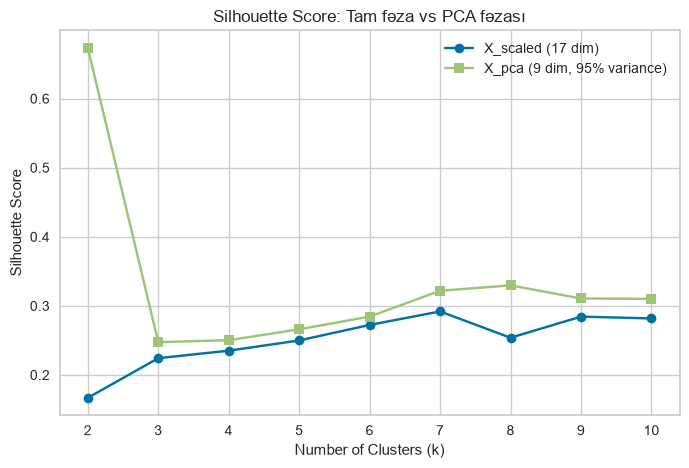

In [60]:
plt.figure(figsize=(8,5))
plt.plot(np.arange(2,11), scores, marker="o", label="X_scaled (17 dim)")
plt.plot(np.arange(2,11), scores_pca, marker="s", label="X_pca (9 dim, 95% variance)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score: Tam fəza vs PCA fəzası")
plt.legend()
plt.grid(True)
plt.show()

**Nəticə:** PCA fəzasında (9 komponent) silhouette dəyərləri tam fəzadakı (17 dəyişən) dəyərlərlə çox oxşar trend göstərir (məs. k=5: 0.2660 vs 0.2499; hər ikisində k=2-də süni şəkildə yüksək dəyər, sonra düşüb tədricən artma). Bu bənzərlik, seçilmiş k=5 qərarının yalnız yüksək ölçülü fəzanın "curse of dimensionality" effektindən qaynaqlanmadığını, nisbətən sabit bir strukturu əks etdirdiyini təsdiqləyir — yəni PCA-reduced fəzada da eyni ümumi pattern qorunur.

## K-Means Clustering

In [61]:
kmeans = KMeans(n_clusters=5, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [62]:
print(kmeans.cluster_centers_)

[[ 1.79194639e+00 -9.70724191e-02  6.76742527e-01  2.34565551e-01
   1.75677399e+00  1.27193654e+00 -7.24193319e-03 -8.77408475e-02
   3.79386667e-01  5.97458047e-01  1.01271186e+00  7.30932203e-01
   3.13732273e-01  8.37243304e-01  3.57005480e+01  1.97739520e-02
  -8.47457627e-02]
 [-3.82311508e-01 -5.14000324e+00  1.81584290e-02  2.68000829e-01
   2.12122379e-01  3.31741087e-01 -2.03066586e-01 -1.26442143e-02
   1.05122092e-01  1.89285889e-01  2.18128109e-01 -9.56934080e-02
   1.48892667e-01  1.66530310e-01 -2.19814597e-01  1.88810706e+00
  -7.60572139e-01]
 [ 2.37546912e+00 -3.94862091e-01  2.57406860e+01  3.86493265e+01
   1.16790511e+01  8.70975093e-01  4.86086533e-01  2.55555681e+00
   7.22704812e-01  1.79347875e-01  4.45652174e-01  7.57608696e+00
   2.66193434e+00  1.77254369e+01  4.90951785e+00  3.60721682e+00
  -8.69565217e-02]
 [ 8.06906848e-01 -2.17857204e-01  3.98249666e+00  5.09498628e+00
   3.32107919e+00  8.18991301e-01  5.07838858e-01  1.98326971e+00
   7.32998334e-01  

In [63]:
df["Cluster"].value_counts().sort_index()

Cluster
0      59
1    1608
2      23
3     889
4    6371
Name: count, dtype: int64

In [64]:
cluster_centers_pca=pca.transform(kmeans.cluster_centers_)

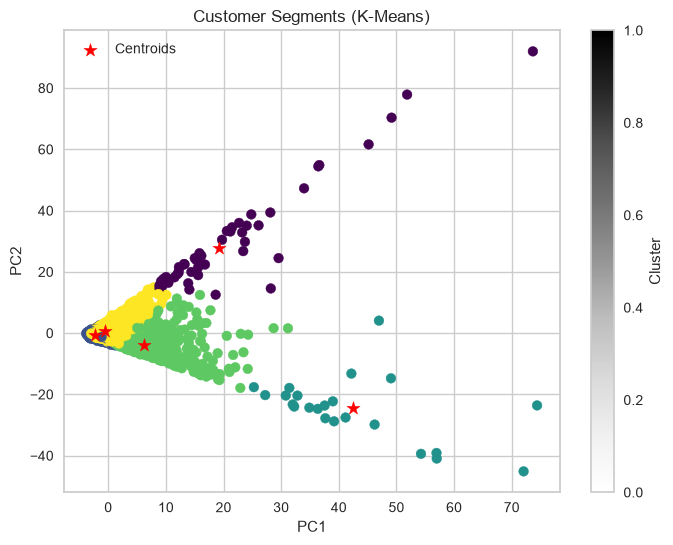

In [65]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"],
    cmap="viridis"
)

# Centroidlər
plt.scatter(
    cluster_centers_pca[:,0],
    cluster_centers_pca[:,1],
    color="red",
    marker="*",
    s=100,
    label="Centroids"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (K-Means)")
plt.legend()
plt.colorbar(label="Cluster")

plt.show()

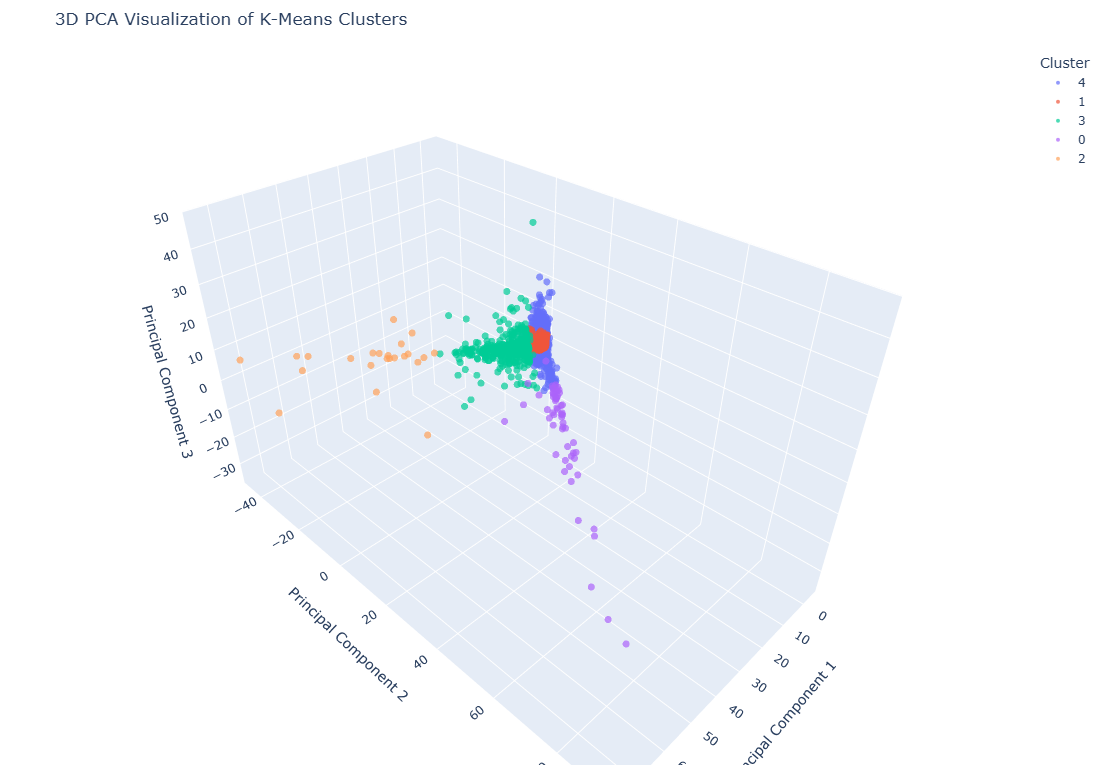

In [66]:
fig = px.scatter_3d(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    z=X_pca[:, 2],
    color=df["Cluster"].astype(str),
    labels={
        "x": "Principal Component 1",
        "y": "Principal Component 2",
        "z": "Principal Component 3",
        "color": "Cluster"
    },
    title="3D PCA Visualization of K-Means Clusters"
)
fig.update_traces(
    marker=dict(
        size=4,
        opacity=0.7
    )
)
fig.update_layout(
    width=1100,
    height=750,
    margin=dict(l=0, r=0, b=0, t=50)
)
fig.show()

In [67]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True).round(2)
cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,BALANCE_TO_LIMIT,TOTAL_TRANSACTIONS,HAS_CASH_ADVANCE,HAS_PURCHASES
Cluster,,,,,,,,,,,,,,,,,,,,,
0,4324.42,0.99,1085.73,173.44,912.29,1416.71,0.49,0.06,0.45,0.13,...,18.69,4537.29,2127.72,22370.14,0.00,11.92,1.03,22.75,0.56,0.73
1,137.11,0.43,380.72,192.75,188.41,369.50,0.33,0.08,0.25,0.04,...,5.47,3729.57,1109.67,176.53,0.27,11.24,0.05,6.34,0.27,0.81
2,5448.20,0.96,27916.56,22354.31,5562.24,970.11,0.91,0.85,0.71,0.04,...,128.22,16043.48,27761.60,3345.72,0.52,11.91,0.36,130.00,0.17,1.00
3,2427.37,0.98,4624.52,2979.87,1645.38,912.21,0.92,0.68,0.72,0.09,...,60.84,7844.26,4865.43,1069.36,0.33,11.88,0.31,63.42,0.30,1.00
4,1764.75,0.98,557.08,285.50,271.79,1137.95,0.47,0.17,0.34,0.17,...,10.16,4177.75,1355.81,773.91,0.10,11.53,0.48,14.10,0.56,0.73


### Klaster profilləri

#### Cluster 0 — Yüksək balanslı müştərilər

Cluster 0-da `BALANCE` (**4324.42**) və `BALANCE_FREQUENCY` (**0.99**) yüksək səviyyədədir. Buna baxmayaraq, alış-veriş aktivliyi VIP və aktiv müştəri klasterləri ilə müqayisədə daha aşağıdır. `CASH_ADVANCE` (**1416.71**) və `HAS_CASH_ADVANCE` (**0.56**) göstəriciləri də bu müştərilərin cash advance istifadəsinə meyilli olduğunu göstərir. Bu səbəbdən Cluster 0 **yüksək balans saxlayan və nisbətən yüksək ödəniş öhdəliyinə malik müştərilər** kimi xarakterizə edilə bilər.

#### Cluster 1 — Passiv istifadəçilər

Cluster 1-də `BALANCE` (**137.11**), `BALANCE_FREQUENCY` (**0.43**) və `TOTAL_TRANSACTIONS` (**6.34**) göstəriciləri çox aşağıdır. `PURCHASES` (**380.72**) və `PURCHASES_TRX` (**5.47**) də aşağı səviyyədə olduğundan bu müştərilərin alış-veriş aktivliyi zəifdir. `BALANCE_TO_LIMIT` (**0.05**) göstəricisi onların kredit limitindən çox az istifadə etdiyini göstərir. Buna görə Cluster 1 **passiv və aşağı kart istifadə intensivliyinə malik müştərilər** kimi xarakterizə edilə bilər.

#### Cluster 2 — VIP / Yüksək dəyərli müştərilər

Cluster 2 cəmi **23 müştəridən** ibarət olsa da, bütün klasterlər arasında ən yüksək müştəri dəyərinə malikdir. `PURCHASES` (**27916.56**), `PAYMENTS` (**27761.60**), `PURCHASES_TRX` (**128.22**), `TOTAL_TRANSACTIONS` (**130.00**) və `CREDIT_LIMIT` (**16043.48**) göstəriciləri ən yüksək səviyyədədir. Bundan əlavə, `PURCHASES_FREQUENCY` (**0.91**) və `HAS_PURCHASES` (**1.00**) bu müştərilərin çox aktiv alış-veriş etdiyini göstərir. Buna görə Cluster 2 **VIP / yüksək dəyərli müştərilər** kimi müəyyən edilir.

#### Cluster 3 — Aktiv alış-veriş edən müştərilər

Cluster 3-də `PURCHASES` (**4624.52**), `PURCHASES_FREQUENCY` (**0.92**), `PURCHASES_TRX` (**60.84**) və `TOTAL_TRANSACTIONS` (**63.42**) yüksək səviyyədədir. Həm `ONEOFF_PURCHASES_FREQUENCY` (**0.68**), həm də `PURCHASES_INSTALLMENTS_FREQUENCY` (**0.72**) yüksək olduğundan müştərilər həm birdəfəlik, həm də taksitli alış-verişdən aktiv istifadə edirlər. Cluster 2 ilə müqayisədə xərcləmə səviyyəsi daha aşağı olsa da, bu qrup **aktiv və yüksək potensiala malik müştərilər** kimi xarakterizə edilə bilər.

#### Cluster 4 — Aşağı-orta aktivlikli müştərilər

Cluster 4 **6371 müştəri** ilə ən böyük klasterdir. `PURCHASES` (**557.08**), `PURCHASES_TRX` (**10.16**) və `TOTAL_TRANSACTIONS` (**14.10**) göstəriciləri aşağı-orta səviyyədədir. `PURCHASES_FREQUENCY` (**0.47**) müştərilərin alış-veriş tezliyinin yüksək olmadığını göstərir. Eyni zamanda `CASH_ADVANCE` (**1137.95**) və `HAS_CASH_ADVANCE` (**0.56**) göstəriciləri müəyyən qədər cash advance istifadəsinin olduğunu göstərir. Buna görə Cluster 4 **böyük, lakin aşağı-orta kart istifadə intensivliyinə malik müştəri seqmenti** kimi xarakterizə edilə bilər.

### Klasterlərin ümumi xülasəsi

| Cluster | Ölçü | Müştəri seqmenti | Əsas xüsusiyyət |
|---|---:|---|---|
| **0** | 59 | Yüksək balanslı | Yüksək balans və yüksək ödəniş öhdəliyi |
| **1** | 1608 | Passiv istifadəçi | Aşağı balans və aşağı əməliyyat aktivliyi |
| **2** | **23** | **VIP / Yüksək dəyərli** | Ən yüksək alış-veriş, ödəniş və əməliyyat aktivliyi |
| **3** | 889 | Aktiv alış-veriş edən | Yüksək alış-veriş tezliyi və əməliyyat sayı |
| **4** | 6371 | Aşağı-orta aktivlikli | Ən böyük seqment və orta-aşağı istifadə intensivliyi |

### Klaster Stabilliyi Testi (Random Seed Həssaslığı)

Seçilmiş K-Means modelinin (k=5) nə dərəcədə sabit olduğunu yoxlamaq üçün fərqli `random_state` dəyərləri ilə model yenidən öyrədilir və hər dəfə əldə olunan etiketlər əsas modelin (`random_state=42`) etiketləri ilə **Adjusted Rand Index (ARI)** vasitəsilə müqayisə edilir. ARI 1-ə nə qədər yaxındırsa, klasterləşmə bir o qədər stabildir (0-a yaxın dəyər təsadüfi uyğunluq deməkdir).

In [68]:
from sklearn.metrics import adjusted_rand_score

base_labels = df["Cluster"]
ari_scores = []

for seed in range(10):
    km = KMeans(n_clusters=5, random_state=seed, n_init=10)
    labels_seed = km.fit_predict(X_scaled)
    ari = adjusted_rand_score(base_labels, labels_seed)
    ari_scores.append(ari)
    print(f"random_state={seed}: ARI = {ari:.4f}")

print(f"\nOrtalama ARI: {np.mean(ari_scores):.4f}")
print(f"Standart sapma: {np.std(ari_scores):.4f}")

random_state=0: ARI = 0.2285
random_state=1: ARI = 0.2283
random_state=2: ARI = 0.7149
random_state=3: ARI = 0.2276
random_state=4: ARI = 0.2308
random_state=5: ARI = 0.2283
random_state=6: ARI = 0.2280
random_state=7: ARI = 0.2286
random_state=8: ARI = 0.7282
random_state=9: ARI = 0.2235

Ortalama ARI: 0.3267
Standart sapma: 0.1975


random_state=3: ARI = 0.2276
random_state=4: ARI = 0.2308
random_state=5: ARI = 0.2283


random_state=6: ARI = 0.2280
random_state=7: ARI = 0.2286
random_state=8: ARI = 0.7282


random_state=9: ARI = 0.2235

Ortalama ARI: 0.3267
Standart sapma: 0.1975


**Nəticə:** Bu test vacib bir məhdudiyyəti üzə çıxardı — nəticələr gözlənildiyindən qeyri-sabitdir. 10 fərqli `random_state` ilə orta ARI cəmi **0.3267** (standart sapma 0.1975) təşkil edir; əksər seed-lər (~0.23) əsas modellə (seed=42) yalnız zəif üst-üstə düşür, yalnız 2 seed (2 və 8) daha yüksək uyğunluq (≈0.72–0.73) göstərir. Bu onu deməkdir ki, K-Means-in bu datasetdə fərqli təsadüfi başlanğıc mərkəzlərlə fərqli lokal optimuma yaxınlaşma ehtimalı yüksəkdir (əsas modeldə `n_init` defolt dəyəri istifadə olunub). **Praktiki tövsiyə:** İstehsalat (production) mühitində istifadə üçün `KMeans(n_clusters=5, random_state=42, n_init=20)` kimi daha yüksək `n_init` dəyəri ilə modelin sabitliyini artırmaq tövsiyə olunur. Bu tapıntı, əvvəlki bölmələrdə qeyd olunan "Silhouette Score-un mütləq etibarlı olmaması" fikrini əlavə sübutla dəstəkləyir.

## Agglomerative Clustering

In [69]:
methods = ["ward", "single", "complete", "average"]
for method in methods:

    model = AgglomerativeClustering(
        n_clusters=5,
        linkage=method
    )
    
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"{method}: {score:.3f}")

ward: 0.197
single: 0.845
complete: 0.700
average: 0.844


single: 0.845


complete: 0.700


average: 0.844


## Hər bir linkage meyarı (single, complete, average, ward) üçün dendroqram

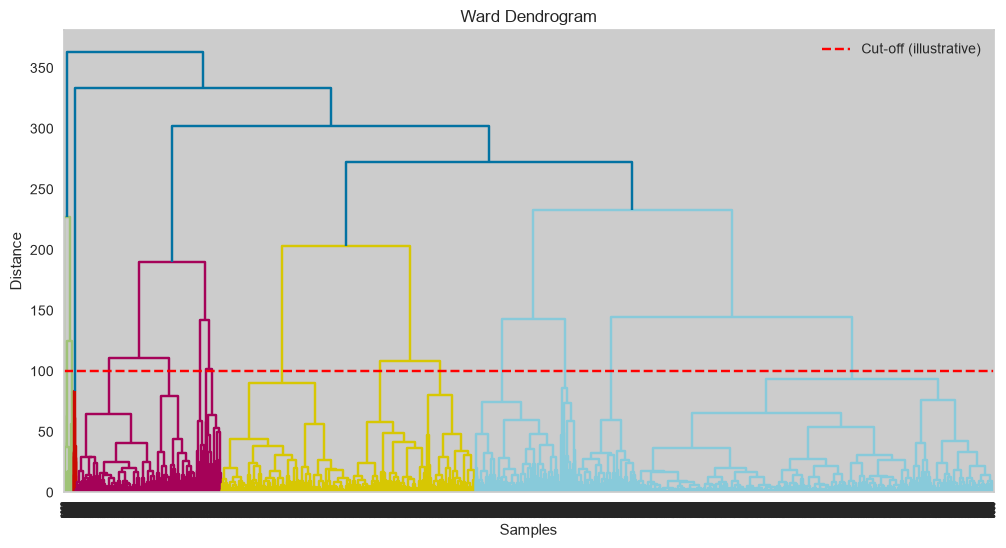

In [70]:
Z = linkage(X_scaled, method="ward")
plt.figure(figsize=(12,6))
dendrogram(Z)
# NOT: bu xətt sadəcə illüstrativdir; real 5-klaster qərarı aşağıda
# fcluster(Z, t=5, criterion='maxclust') ilə verilib, məsafə həddi ilə deyil.
plt.axhline(y=100, color="red", linestyle="--", label="Cut-off (illustrative)")
plt.legend()
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.title("Ward Dendrogram")
plt.show()

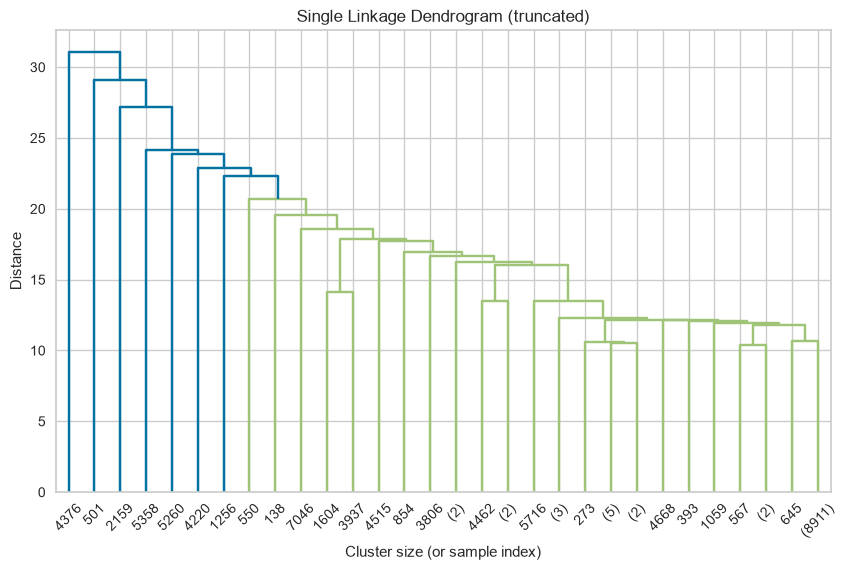

In [71]:
Z = linkage(X_scaled, method="single")

plt.figure(figsize=(10, 6))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title("Single Linkage Dendrogram (truncated)")
plt.xlabel("Cluster size (or sample index)")
plt.ylabel("Distance")
plt.show()

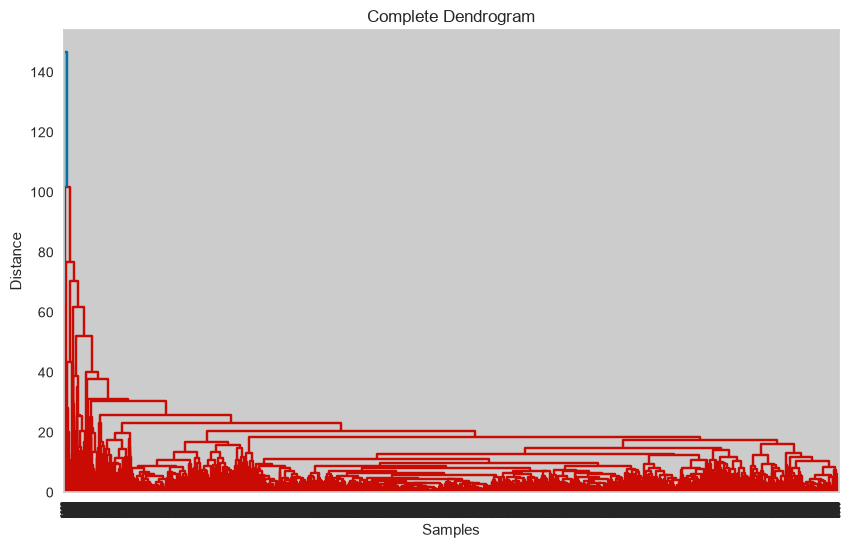

In [72]:
Z = linkage(X_scaled, method="complete")

plt.figure(figsize=(10,6))
dendrogram(Z)
plt.title("Complete Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

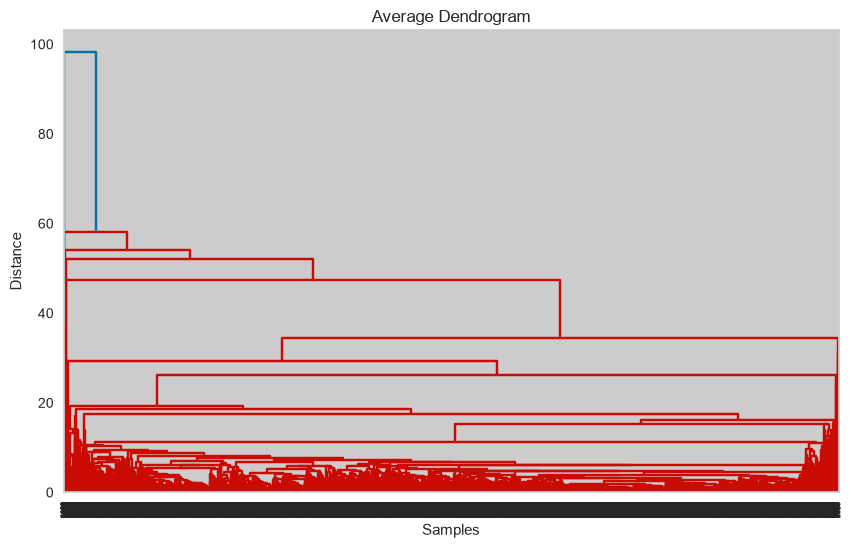

In [73]:
Z = linkage(X_scaled, method="average")

plt.figure(figsize=(10,6))
dendrogram(Z)
plt.title("Average Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

Qrafiklərdən də göründüyü kimi ən doğru seçim **warddır**.

In [74]:
Z = linkage(X_scaled, method="ward")
hc_labels = fcluster(Z, t=5, criterion='maxclust')

print("HC labels sayı:", len(hc_labels))
print("Unikal dəyərlər:", set(hc_labels))

# K-Means (PCA fəzası) ilə Hierarchical (scaled fəza) klasterlərinin müqayisəsi
comparison = pd.crosstab(df["Cluster"], hc_labels)
print(comparison)

HC labels sayı: 8950
Unikal dəyərlər: {np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)}
col_0     1   2    3     4     5
Cluster                         
0        55   0    3     0     1
1         0   0    2  1531    75
2         0  19    4     0     0
3         3   0  750    68    68
4        42   0  645   846  4838


### K-Means və Hierarchical Clustering müqayisəsi

Cross-tab nəticələrinə görə: K-Means Cluster 1 (1608 nəfər) demək olar tam Ward-un 4-cü klasterinə uyğun gəlir (1531/1608). K-Means Cluster 4 (6371 nəfər, ən böyük qrup) əsasən Ward-un 5-ci klasteri ilə üst-üstə düşür (4838/6371), amma bir hissəsi (846) Ward-un 4-cü klasterinə düşür. K-Means Cluster 0 (59 nəfər — yüksək risk qrupu) Ward-da əsasən 1-ci klasterlə üst-üstə düşür (55/59). Ekstremal kiçik qruplar (Cluster 0 və 2) hər iki metodda ayrıca klaster kimi qalıb, bu da onların həqiqətən fərqli (outlier) davranış nümunəsi olduğunu təsdiqləyir.


In [75]:
model = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)
df["HC_Cluster"] = model.fit_predict(X_scaled)

In [76]:
df["HC_Cluster"].value_counts().sort_index()

HC_Cluster
0    4982
1     100
2      19
3    1404
4    2445
Name: count, dtype: int64

### Single Linkage metodunun qiymətləndirilməsi

**Silhouette skorları** (linkage müqayisəsi): ward=0.197, single=0.845, complete=0.700, average=0.844. Single və Average linkage-də süni şəkildə yüksək skor **chaining effect**-dən qaynaqlanır (demək olar bütün müşahidələr bir klasterə düşür, qalanlar isə tək-tək kiçik klasterlərdir) — bu, keyfiyyətli seqmentasiya demək deyil. Buna görə Ward linkage seçilib.
Single Linkage metodu ən yüksək Silhouette Score əldə etsə də, klasterlərin paylanması balanslı olmadı. Nəticədə müştərilərin böyük əksəriyyəti eyni klasterdə toplandı, digər klasterlər isə çox az sayda müştəridən ibarət oldu.

Bu vəziyyət **Single Linkage** metodunun məşhur **"chaining effect"** (zəncirvari birləşmə) problemi ilə izah olunur. Bu metod yalnız iki klaster arasındakı ən yaxın nöqtələri nəzərə aldığı üçün bir-birinə yaxın olan müşahidələri ardıcıl şəkildə birləşdirir. Nəticədə çox böyük bir klaster və bir neçə çox kiçik klaster yaranır.

Belə bir bölgü müştəri seqmentasiyası üçün uyğun hesab edilmir. Çünki müştərilərin böyük hissəsi eyni klasterdə toplandıqda, klasterlər arasında mənalı fərqlər müəyyən etmək və hər qrup üçün ayrıca marketinq strategiyası hazırlamaq çətinləşir.

Bu səbəbdən, **Silhouette Score** bir qədər aşağı olsa da, **Ward Linkage** metodu seçilmişdir. Ward metodu klasterdaxili variasiyanı minimuma endirdiyi üçün daha balanslı və interpretasiya edilə bilən klasterlər yaradır. Bu da müştəri seqmentasiyası üçün daha praktik və etibarlı nəticələr təqdim edir.

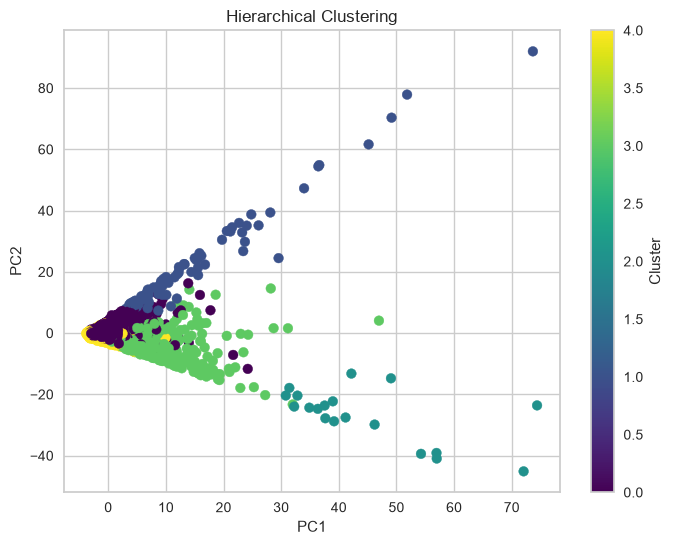

In [77]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["HC_Cluster"],
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clustering")

plt.colorbar(label="Cluster")

plt.show()

## DBSCAN

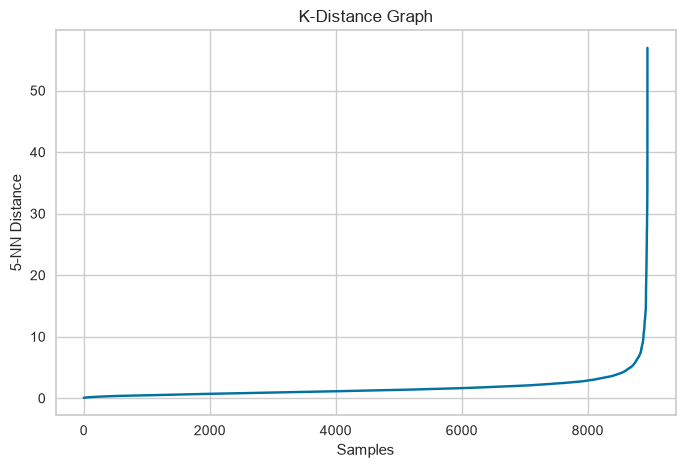

In [78]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.xlabel("Samples")
plt.ylabel("5-NN Distance")
plt.title("K-Distance Graph")
plt.grid(True)
plt.show()

In [79]:
# K-distance qrafikindən tövsiyə olunan aralıq (~2.5-3.0) daxil edilməklə daha geniş sınaq aparılır
for eps in [2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0]:

    labels = DBSCAN(
        eps=eps,
        min_samples=5
    ).fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    print(f"eps={eps:.2f} → clusters={n_clusters}, noise={n_noise}")


eps=2.40 → clusters=4, noise=1058
eps=2.60 → clusters=3, noise=868
eps=2.80 → clusters=2, noise=746
eps=3.00 → clusters=5, noise=630
eps=3.20 → clusters=2, noise=544
eps=3.40 → clusters=4, noise=466
eps=3.60 → clusters=3, noise=396
eps=3.80 → clusters=1, noise=349
eps=4.00 → clusters=2, noise=318


eps=2.60 → clusters=3, noise=868


eps=2.80 → clusters=2, noise=746


eps=3.00 → clusters=5, noise=630


eps=3.20 → clusters=2, noise=544


eps=3.40 → clusters=4, noise=466


eps=3.60 → clusters=3, noise=396


eps=3.80 → clusters=1, noise=349


eps=4.00 → clusters=2, noise=318


K-Distance Graph əsasında DBSCAN üçün `eps` dəyəri 2.4–4.0 aralığında sınaqdan keçirildi:

| eps | Cluster sayı | Noise (outlier) sayı |
|---:|---:|---:|
| 2.4 | 4 | 1058 |
| 2.6 | 3 | 868 |
| 2.8 | 2 | 746 |
| 3.0 | 5 | 630 |
| 3.2 | 2 | 544 |
| 3.4 | 4 | 466 |
| 3.6 | 3 | 396 |
| 3.8 | 1 | 349 |
| 4.0 | 2 | 318 |

Nəticə qeyri-sabitdir — `eps` dəyəri artdıqca cluster sayı monoton şəkildə dəyişmir (2→5→2→4→3→1→2), bu da sıxlıq-əsaslı struktur üçün DBSCAN-ın bu datasetdə (yüksək ölçülü, qeyri-bərabər sıxlıqlı fəzada) sabit nəticə vermədiyini göstərir. `eps=3.0` nisbətən məqbul say (5 klaster, 630 noise, ~7%) versə də, ümumilikdə DBSCAN bu dataset üçün etibarlı seqmentasiya vermir.


## Gaussian Mixture Model (GMM)

**Qeyd:** GMM burada tam kovaryans matrisi (`covariance_type="full"`, default) ilə 17 ölçülü fəzada işlədilir. Yüksək ölçülü fəzada full-covariance GMM parametr sayının sürətlə artması səbəbindən overfitting-ə meyllidir; nəticələr bu baxımdan ehtiyatla dəyərləndirilməlidir.


In [80]:
scores = []

for k in range(2, 11):
    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )
    labels = gmm.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"k = {k}: {score:.4f}")

k = 2: 0.0841
k = 3: 0.0346
k = 4: 0.0154
k = 5: -0.0016
k = 6: -0.0083
k = 7: 0.0439
k = 8: 0.0173
k = 9: -0.0279
k = 10: -0.0177


k = 3: 0.0346


k = 4: 0.0154


k = 5: -0.0016


k = 6: -0.0083


k = 7: 0.0439


k = 8: 0.0173


k = 9: -0.0279


k = 10: -0.0177


Optimal komponent sayını müəyyən etmək üçün **2–10** aralığında müxtəlif komponent sayları sınaqdan keçirilmiş və hər biri üçün **Silhouette Score** hesablanmışdır.

| Komponent sayı (k) | Silhouette Score |
|---:|---:|
| **2** | **0.0841** |
| 3 | 0.0346 |
| 4 | 0.0154 |
| 5 | -0.0016 |
| 6 | -0.0083 |
| 7 | 0.0439 |
| 8 | 0.0173 |
| 9 | -0.0279 |
| 10 | -0.0177 |

Nəticələr göstərir ki, ən yüksək **Silhouette Score (0.0841)** **k=2** üçün əldə edilmişdir, amma bu dəyər çox aşağıdır və klasterlərin zəif ayrıldığını göstərir. Komponent sayı artdıqca skor qeyri-sabit dəyişir və bir çox k dəyərində mənfi olur (klasterlərin üst-üstə düşdüyünü göstərir).


In [81]:
aic=[]
bic=[]
for k in range(1,11):
    gmm=GaussianMixture(n_components=k,random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

Text(0, 0.5, 'Score')

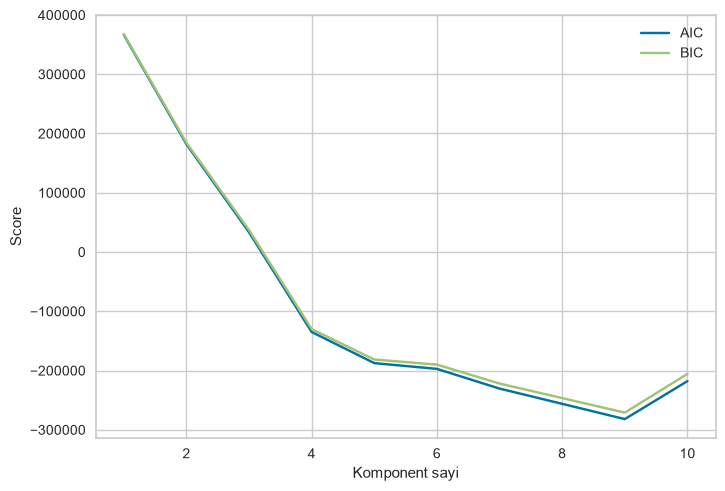

In [82]:
plt.plot(range(1,11),aic,label="AIC")
plt.plot(range(1,11),bic,label="BIC")
plt.legend()
plt.xlabel("Komponent sayi")
plt.ylabel("Score")

GMM modelində komponent sayının müəyyən edilməsi üçün AIC və BIC dəyərləri müqayisə edilmişdir. Bu göstəricilərdə **daha aşağı qiymət** daha yaxşı model seçimini göstərir.

Qrafikə əsasən AIC və BIC dəyərləri komponent sayı artdıqca sürətlə azalır və ən aşağı səviyyəyə **k=9** ətrafında çatır (AIC ≈ -281 985, BIC ≈ -271 067). `k=10` üçün isə hər iki göstəricidə artım müşahidə olunur.

AIC və BIC nəticələrinə əsasən **9 komponent** GMM üçün uyğun seçim kimi görünür. Lakin Silhouette Score bütün k dəyərlərində çox aşağı (əksər hallarda mənfi) olduğundan, GMM-in bu datasetdə aydın, yaxşı ayrılmış klaster strukturu tapa bilmədiyi qənaətinə gəlinir.


In [83]:
gmm = GaussianMixture(
    n_components=2,
    random_state=42
)
df["GMM_Cluster"] = gmm.fit_predict(X_scaled)

In [84]:
df["GMM_Cluster"].value_counts().sort_index()

GMM_Cluster
0    4761
1    4189
Name: count, dtype: int64

In [85]:
gmm = GaussianMixture(
    n_components=9,
    random_state=42
)
df["GMM_Cluster"] = gmm.fit_predict(X_scaled)

In [86]:
df["GMM_Cluster"].value_counts().sort_index()

GMM_Cluster
0    1635
1     778
2     646
3       7
4    2079
5     188
6     986
7    1323
8    1308
Name: count, dtype: int64

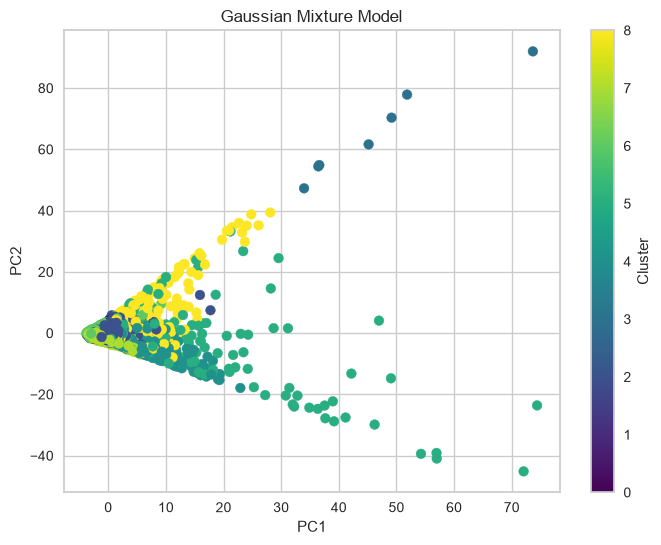

In [87]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["GMM_Cluster"],
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Gaussian Mixture Model")

plt.colorbar(label="Cluster")
plt.show()

### Nəticə
GMM-də müxtəlif komponent sayları yoxlanılmışdır. Silhouette Score k=2 üçün nisbi ən yüksək olsa da (0.084), mütləq dəyər çox aşağıdır və k=5-dən başlayaraq mənfi olur — bu, GMM-in bu datasetdə aydın ayrılmış klasterlər tapa bilmədiyini göstərir. AIC/BIC daha çox komponentli modellərə (k=9) üstünlük versə də, müştəri seqmentlərinin sadə interpretasiyası baxımından KMeans (k=5, RobustScaler) daha aydın və praktik nəticə vermişdir.


## Anomaly Detection

In [88]:
for c in [0.01, 0.02, 0.03, 0.05]:
    iso = IsolationForest(
        contamination=c,
        random_state=42
    )
    labels = iso.fit_predict(X_scaled)
    print(f"contamination={c}: {(labels==-1).sum()} anomaliya")

contamination=0.01: 90 anomaliya
contamination=0.02: 179 anomaliya
contamination=0.03: 269 anomaliya
contamination=0.05: 448 anomaliya


contamination=0.03: 269 anomaliya
contamination=0.05: 448 anomaliya


### Isolation Forest üçün contamination seçimi

Müxtəlif `contamination` dəyərləri sınaqdan keçirilmişdir:

| Contamination | Anomaliya sayı |
|---:|---:|
| 0.01 | 90 |
| **0.02** | **179** |
| 0.03 | 269 |
| 0.05 | 448 |

Bu layihədə **`contamination=0.02`** seçilmişdir. Bu seçim çox az sayda 
anomaliya müəyyən etməklə çox sayda müştərini anomaliya kimi işarələmək 
arasında daha balanslı nəticə təqdim edir.

Nəticədə 8950 müştərinin **179-u (2%)** anomaliya kimi müəyyən edilmişdir. 
Bu yanaşma datasetdəki ən qeyri-adi müştəriləri müəyyən etmək üçün uyğun 
hesab edilmişdir.

In [89]:
iso = IsolationForest(
    contamination=0.02,
    random_state=42
)
df["Anomaly"] = iso.fit_predict(X_scaled)

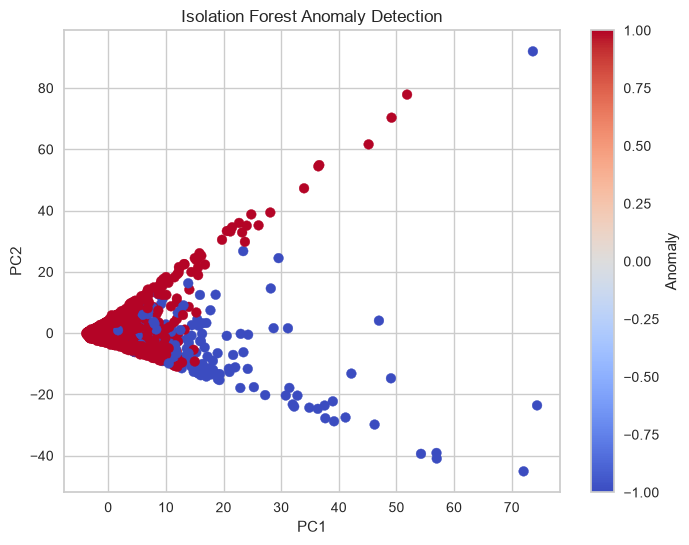

In [90]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Anomaly"],
    cmap="coolwarm"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Isolation Forest Anomaly Detection")

plt.colorbar(label="Anomaly")

plt.show()

In [91]:
# Anomaliya kimi işarələnmiş müştəriləri ayrıca DataFrame-də saxlayırıq
anomalies = df[df["Anomaly"] == -1]
anomalies.shape

(179, 26)

In [92]:
# VIP klasteri anomaliyalarla üst-üstə düşürmü?
crosstab_anomaly = pd.crosstab(df["Cluster"], df["Anomaly"])
crosstab_anomaly.columns = ["Anomaly (-1)", "Normal (1)"]
crosstab_anomaly


,Anomaly (-1),Normal (1)
Cluster,,
0,6,53
1,0,1608
2,23,0
3,128,761
4,22,6349


Isolation Forest ilə (`contamination=0.02`) ümumilikdə **179 müştəri (~2%)** anomaliya kimi işarələnmişdir. Cross-tab nəticələri çox aydın bir nümunə göstərir:

| Cluster | Ölçü | Anomaliya sayı | Anomaliya faizi |
|---:|---:|---:|---:|
| 0 | 59 | 6 | 10.2% |
| 1 | 1608 | 0 | 0.0% |
| **2** | **23** | **23** | **100%** |
| 3 | 889 | 128 | 14.4% |
| 4 | 6371 | 22 | 0.3% |

**Ən diqqətçəkən tapıntı:** Cluster 2-dəki bütün 23 müştəri (100%) anomaliya kimi işarələnib. Bu klaster ən yüksək `PURCHASES`, `PAYMENTS` və `TOTAL_TRANSACTIONS` göstəricilərinə malik ultra-VIP seqmentdir — Isolation Forest onları statistik cəhətdən 'normal' müştəri davranışından tam kənar hesab edib. 

Cluster 3-də də nisbətən yüksək anomaliya payı (14.4%) müşahidə olunur — bu, orta-yüksək aktivlikli, lakin bəzi hallarda ekstremal dəyərlərə malik müştəriləri əhatə edir.

Cluster 1 (passiv seqment, 1608 nəfər) və Cluster 4 (böyük əksəriyyət, 6371 nəfər) demək olar ki, anomaliyasızdır (0% və 0.3%) — bu, onların 'tipik' davranış nümunəsini təmsil etdiyini təsdiqləyir.


In [93]:
df["Anomaly"].value_counts()

Anomaly
 1    8771
-1     179
Name: count, dtype: int64

- Isolation Forest verilənlərdə normal və qeyri-adi müşahidələri müəyyən etdi.
- -1 ilə işarələnən sətirlər potensial anomaliyalardır.
- 1 ilə işarələnənlər normal müştərilərdir.

<h2 align="center"><b>Yekun Nəticə və Biznes Tövsiyələri</b></h2>

### Seçilən model: K-Means (k=5, RobustScaler)

Müştəri seqmentasiyası üçün bir neçə klasterləşmə metodu, o cümlədən **K-Means, Agglomerative/Ward, DBSCAN və GMM** sınaqdan keçirilmişdir. Modellərin seçilməsi zamanı **Elbow Method, Silhouette Score, AIC/BIC və Hierarchical Clustering** nəticələrindən istifadə edilmişdir.

**K-Means (k=5)** əsas model kimi seçilmişdir, çünki:

- **Elbow Method** k=5-6 ətrafında diminishing-returns nöqtəsi göstərmişdir; Silhouette Score isə k ilə monoton (qeyri-stabil) artdığından tək başına etibarlı meyar deyil.
- Ward Hierarchical Clustering ilə müqayisədə klasterlər arasında **əhəmiyyətli uyğunluq** müşahidə edilmişdir — xüsusilə ekstremal kiçik klasterlər (0 və 2) hər iki metodda ayrıca qrup kimi seçilmişdir, bu da onların real, təsadüfi olmayan struktur olduğunu təsdiqləyir.
- **DBSCAN** qeyri-sabit nəticələr vermiş və effektiv seqmentasiya təmin etməmişdir.
- **GMM** üçün Silhouette Score bütün k dəyərlərində aşağı (əksərən mənfi) olmuş, AIC/BIC isə k=9-u tövsiyə etmişdir — bu ziddiyyət GMM-in bu datasetdə etibarlı struktur tapmadığını göstərir.
- K-Means nəticəsində əldə edilən 5 klaster, RobustScaler ilə birlikdə, **statistik cəhətdən daha dəqiq və biznes baxımından fərqləndirici** müştəri seqmentləri yaratmışdır — o cümlədən əvvəllər gizli qalan iki kiçik, lakin kritik əhəmiyyətli ekstremal qrup (yüksək risk və ultra-VIP) aşkarlanmışdır.

### Klaster profilləri və tövsiyələr

| Klaster | Ölçü | Xarakteristika | Tövsiyə |
|---|---:|---|---|
| **0 — Yüksək Risk / Borc yükü ağır** | 59 | `BALANCE_TO_LIMIT` ≈ 1.03 (limitini keçib), `MINIMUM_PAYMENTS` ortalama 22 370 (ekstremal), heç vaxt tam ödəməyib (`PRC_FULL_PAYMENT`=0) | Təcili risk monitorinqi, fərdi borc idarəetmə planları, kredit limitinin nəzərdən keçirilməsi |
| **1 — Passiv / Aşağı aktivlik** | 1608 | Aşağı balans (137), aşağı istifadə tezliyi (0.43), aşağı kredit limiti (3730) | Aktivləşdirmə kampaniyaları, ilk alış-veriş üçün təşviqlər, kartın 'yenidən xatırladılması' |
| **2 — Ultra-VIP / Top xərcləyənlər** | 23 | Ən yüksək `PURCHASES` (27 917), `PAYMENTS` (27 762), 130 əməliyyat — çox kiçik amma ən dəyərli qrup; **100% anomaliya kimi işarələnib** | Fərdi münasibətçi (relationship manager), premium/black kart təklifləri, xüsusi loyallıq və konsyerj xidmətləri |
| **3 — Aktiv, orta-yüksək dəyərli** | 889 | Orta-yüksək `PURCHASES` (4625), `CREDIT_LIMIT` (7844); nisbətən yüksək anomaliya payı (14.4%) | Cashback və taksitli alış-veriş kampaniyaları, VIP seqmentə keçid potensialının izlənməsi |
| **4 — Standart / Kütləvi seqment** | 6371 | Ən böyük qrup (71%), orta göstəricilər, aşağı `PURCHASES` (557) və aşağı tam ödəmə faizi (0.10) | Ümumi loyallıq proqramları, seqmentə uyğun kütləvi marketinq, tədricən yuxarı seqmentə (cross-sell) yönləndirmə |

### Əlavə tapıntı: Anomaliya Aşkarlanması

Isolation Forest ilə (`contamination=0.02`) ümumilikdə **179 müştəri (~2%)** anomaliya kimi işarələnmişdir. Ən diqqətçəkən nəticə: **Cluster 2-dəki bütün 23 müştəri (100%)** anomaliya kimi qiymətləndirilib — yəni statistik baxımdan ən 'qeyri-adi' davranışa malik olanlar məhz ən yüksək dəyərli müştərilərdir. Cluster 0 (yüksək risk, 10.2%) və Cluster 3 (14.4%) də ortalamadan yüksək anomaliya payına malikdir, Cluster 1 və 4 isə demək olar ki, tam 'normal' davranış nümunəsini əks etdirir (uyğun olaraq 0% və 0.3%).

Bu nəticə göstərir ki, ekstremal seqmentlər (həm ən yüksək risk, həm də ən yüksək dəyər) eyni zamanda statistik anomaliya olaraq da özünü göstərir — bu da onların ayrıca, fərdiləşdirilmiş idarəetmə tələb etdiyini gücləndirir.

### Metodoloji qeydlər

- Outlier-lər IQR metodu ilə aşkarlansa da (BALANCE: 695, PURCHASES: 808, CASH_ADVANCE: 1030, CREDIT_LIMIT: 248), real müştəri davranışını əks etdirdiyi üçün **silinmədi**.
- Outlier-lərin təsirini azaltmaq üçün **`RobustScaler`** istifadə edildi — nəticədə klaster strukturu daha balanssız, lakin daha dəqiq oldu: iki kiçik, statistik cəhətdən aydın fərqlənən ekstremal qrup (yüksək risk və ultra-VIP) aşkarlandı.
- PCA yalnız vizuallaşdırma məqsədilə istifadə olundu; faktiki klasterləşmə tam ölçülü standartlaşdırılmış fəzada aparıldı.
- Klasterləşmənin sağlamlığı **çoxsaylı metod və perspektivin** (elbow, silhouette, hierarchical, GMM, anomaly detection) müqayisəsi ilə yoxlanıldı — tək bir metrikaya güvənilmədi.
